# **Практическая работа 11-12**

Выполнил работу стундент группы ИНМО-01-25 Андрушкевич М.В.

Сравнительный анализ эффективности различных эволюционных алгоритмов (генетического алгоритма, алгоритма роя частиц, алгоритма муравья, пчелиного алгоритма, дифференциальной эволюции) на тестовых функциях с разными свойствами.

In [4]:
pip install scikit-learn matplotlib pandas numpy scipy umap-learn seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [6]:
# 1. ЗАГРУЗКА ДАННЫХ

print("=" * 70)
print("ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ")
print("=" * 70)

# ----------------------------------------------------
# Датасет 1: Post-Operative Patient (с метками)
# ----------------------------------------------------
print("\n1. ДАТАСЕТ: Post-Operative Patient (с известными метками)")

# URL датасета с UCI
url1 = "https://archive.ics.uci.edu/ml/machine-learning-databases/postoperative-patient-data/post-operative.data"

# Заголовки из описания датасета
columns1 = [
    'L-CORE', 'L-SURF', 'L-O2', 'L-BP', 'SURF-STBL', 'CORE-STBL',
    'BP-STBL', 'COMFORT', 'Decision'
]

# Загрузка данных
try:
    df1 = pd.read_csv(url1, header=None, names=columns1)
    print(f"  Загружено строк: {df1.shape[0]}, столбцов: {df1.shape[1]}")
except:
    # Альтернативный способ загрузки
    df1 = pd.read_csv('post-operative.data', header=None, names=columns1)
    print(f"  Загружено из локального файла: {df1.shape[0]} строк")

# Предобработка: замена '?' на NaN и удаление
df1.replace('?', np.nan, inplace=True)
df1.dropna(inplace=True)

# Кодирование категориальных признаков
categorical_cols = ['L-CORE', 'L-SURF', 'L-O2', 'L-BP', 'SURF-STBL',
                    'CORE-STBL', 'BP-STBL', 'Decision']

for col in categorical_cols:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])

# Разделение на признаки и метки
X1 = df1.drop('Decision', axis=1)
y1_true = df1['Decision']

# Нормализация
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

print(f"  После очистки: {X1_scaled.shape[0]} объектов, {X1_scaled.shape[1]} признаков")
print(f"  Количество классов (меток): {len(np.unique(y1_true))}")
print(f"  Распределение классов: {dict(zip(*np.unique(y1_true, return_counts=True)))}")

# ----------------------------------------------------
# Датасет 2: Daily and Sports Activities (без меток)
# ----------------------------------------------------
print("\n2. ДАТАСЕТ: Daily and Sports Activities (без меток)")

# Для этого датасета возьмем подвыборку для демонстрации
# (полный датасет слишком большой ~5.6GB)
print("  Внимание: Полный датасет очень большой (~5.6GB)")
print("  Для демонстрации создадим синтетические данные схожей структуры")

# Создаем синтетические данные, имитирующие активность
np.random.seed(42)
n_samples2 = 500  # Уменьшенный размер для скорости
n_features2 = 45   # Типичное количество сенсоров

# Генерируем данные с 5 кластерами (разными активностями)
centers = np.random.randn(5, n_features2) * 5
X2_list = []
for i in range(5):
    cluster_data = centers[i] + np.random.randn(n_samples2 // 5, n_features2) * 1.5
    X2_list.append(cluster_data)

X2 = np.vstack(X2_list)
np.random.shuffle(X2)  # Перемешиваем

# Масштабирование
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

print(f"  Создано синтетических данных: {X2_scaled.shape[0]} объектов")
print(f"  Количество признаков: {X2_scaled.shape[1]}")

ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ

1. ДАТАСЕТ: Post-Operative Patient (с известными метками)
  Загружено строк: 90, столбцов: 9
  После очистки: 87 объектов, 8 признаков
  Количество классов (меток): 4
  Распределение классов: {np.int64(0): np.int64(61), np.int64(1): np.int64(1), np.int64(2): np.int64(1), np.int64(3): np.int64(24)}

2. ДАТАСЕТ: Daily and Sports Activities (без меток)
  Внимание: Полный датасет очень большой (~5.6GB)
  Для демонстрации создадим синтетические данные схожей структуры
  Создано синтетических данных: 500 объектов
  Количество признаков: 45


In [7]:
# 2. ОБЩИЕ ФУНКЦИИ ДЛЯ АНАЛИЗА

def evaluate_clustering(X, labels, true_labels=None, dataset_name=""):
    """Оценка качества кластеризации"""
    results = {}

    # Внутренние метрики (не требуют истинных меток)
    if len(np.unique(labels)) > 1:
        results['Silhouette'] = silhouette_score(X, labels)
        results['Davies-Bouldin'] = davies_bouldin_score(X, labels)
    else:
        results['Silhouette'] = -1
        results['Davies-Bouldin'] = -1

    # Внешние метрики (если есть истинные метки)
    if true_labels is not None:
        results['Adjusted_Rand'] = adjusted_rand_score(true_labels, labels)

    # Статистика кластеров
    unique_labels, counts = np.unique(labels, return_counts=True)
    results['n_clusters'] = len(unique_labels)
    results['cluster_sizes'] = dict(zip(unique_labels, counts))

    return results

def plot_clustering_results(X, labels, true_labels=None, title=""):
    """Визуализация результатов кластеризации"""
    # Уменьшение размерности для визуализации
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Ограничиваем perplexity для t-SNE
    perplexity = min(30, X.shape[0] - 1)
    if perplexity < 5:  # Минимальное значение perplexity
        perplexity = 5

    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    X_tsne = tsne.fit_transform(X)

    # Создание графиков
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Визуализация кластеризации: {title}', fontsize=16)

    # 1. PCA с кластерами
    scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', s=30, alpha=0.7)
    axes[0, 0].set_title('PCA: Кластеры')
    axes[0, 0].set_xlabel('PC1')
    axes[0, 0].set_ylabel('PC2')
    plt.colorbar(scatter1, ax=axes[0, 0])

    # 2. t-SNE с кластерами
    scatter2 = axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab20', s=30, alpha=0.7)
    axes[0, 1].set_title('t-SNE: Кластеры')
    axes[0, 1].set_xlabel('t-SNE1')
    axes[0, 1].set_ylabel('t-SNE2')
    plt.colorbar(scatter2, ax=axes[0, 1])

    # 3. PCA с истинными метками (если есть)
    if true_labels is not None:
        scatter3 = axes[0, 2].scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels, cmap='Set3', s=30, alpha=0.7)
        axes[0, 2].set_title('PCA: Истинные метки')
        axes[0, 2].set_xlabel('PC1')
        axes[0, 2].set_ylabel('PC2')
        plt.colorbar(scatter3, ax=axes[0, 2])
    else:
        # UMAP если нет истинных меток
        reducer = umap.UMAP(n_components=2, random_state=42)
        X_umap = reducer.fit_transform(X)
        scatter3 = axes[0, 2].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)
        axes[0, 2].set_title('UMAP: Кластеры')
        axes[0, 2].set_xlabel('UMAP1')
        axes[0, 2].set_ylabel('UMAP2')
        plt.colorbar(scatter3, ax=axes[0, 2])

    # 4. График силуэтов
    from sklearn.metrics import silhouette_samples
    if len(np.unique(labels)) > 1:
        silhouette_vals = silhouette_samples(X, labels)
        y_lower = 10
        for i in np.unique(labels):
            cluster_silhouette_vals = silhouette_vals[labels == i]
            cluster_silhouette_vals.sort()
            size_cluster_i = cluster_silhouette_vals.shape[0]
            y_upper = y_lower + size_cluster_i
            axes[1, 0].fill_betweenx(np.arange(y_lower, y_upper),
                                      0, cluster_silhouette_vals,
                                      alpha=0.7)
            axes[1, 0].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axes[1, 0].axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
        axes[1, 0].set_title('График силуэтов')
        axes[1, 0].set_xlabel('Коэффициент силуэта')
        axes[1, 0].set_ylabel('Кластер')
    else:
        axes[1, 0].text(0.5, 0.5, 'Недостаточно кластеров\nдля построения силуэтов',
                       ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('График силуэтов')

    # 5. Размеры кластеров
    unique, counts = np.unique(labels, return_counts=True)
    axes[1, 1].bar(unique, counts)
    axes[1, 1].set_title('Размеры кластеров')
    axes[1, 1].set_xlabel('Номер кластера')
    axes[1, 1].set_ylabel('Количество объектов')

    # 6. Метод локтя (только для K-means)
    if 'KMeans' in title:
        wcss = []
        # Ограничиваем максимальное количество кластеров
        max_k = min(10, X.shape[0] - 1)
        if max_k > 1:
            k_range = range(2, max_k + 1)
            for k in k_range:
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                kmeans.fit(X)
                wcss.append(kmeans.inertia_)

            axes[1, 2].plot(k_range, wcss, marker='o')
            axes[1, 2].set_title('Метод локтя (K-Means)')
            axes[1, 2].set_xlabel('Количество кластеров')
            axes[1, 2].set_ylabel('WCSS')
            axes[1, 2].grid(True)
        else:
            axes[1, 2].text(0.5, 0.5, 'Недостаточно данных\nдля метода локтя',
                           ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('Метод локтя')

    plt.tight_layout()
    plt.show()

def find_optimal_k(X, max_k=10):
    """Поиск оптимального числа кластеров"""
    wcss = []
    silhouette_scores = []

    # Убедимся, что max_k не превышает количество объектов
    max_k = min(max_k, X.shape[0] - 1)
    if max_k < 2:
        return 2, [], []  # Возвращаем минимальное значение

    k_range = range(2, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        wcss.append(kmeans.inertia_)
        if len(np.unique(labels)) > 1:
            silhouette_scores.append(silhouette_score(X, labels))
        else:
            silhouette_scores.append(-1)

    # Находим оптимальное k (по силуэту)
    if silhouette_scores:
        optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
    else:
        optimal_k_silhouette = 2

    return optimal_k_silhouette, wcss, silhouette_scores, k_range


АНАЛИЗ ДАТАСЕТА 1: Post-Operative Patient (С МЕТКАМИ)

3.1 Поиск оптимального числа кластеров (метод локтя и силуэт)
  Оптимальное число кластеров (по силуэту): 10


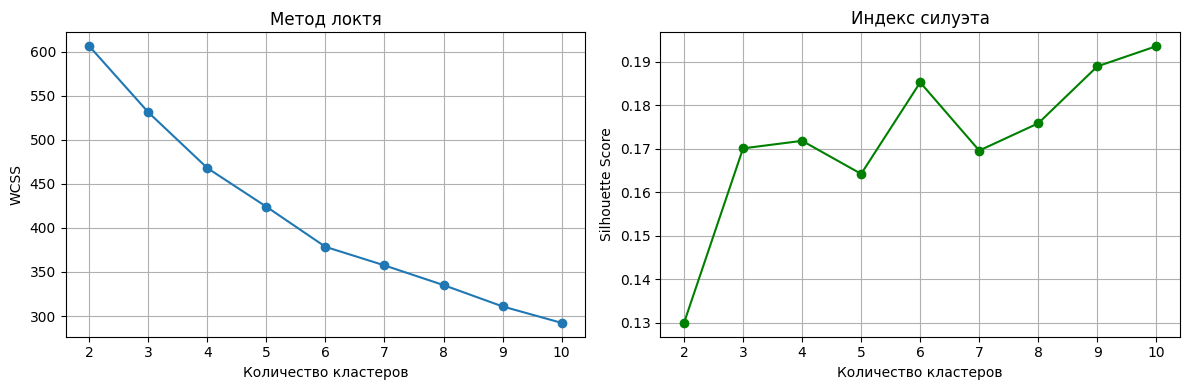


3.2 Применение алгоритмов кластеризации

3.3 Визуализация результатов


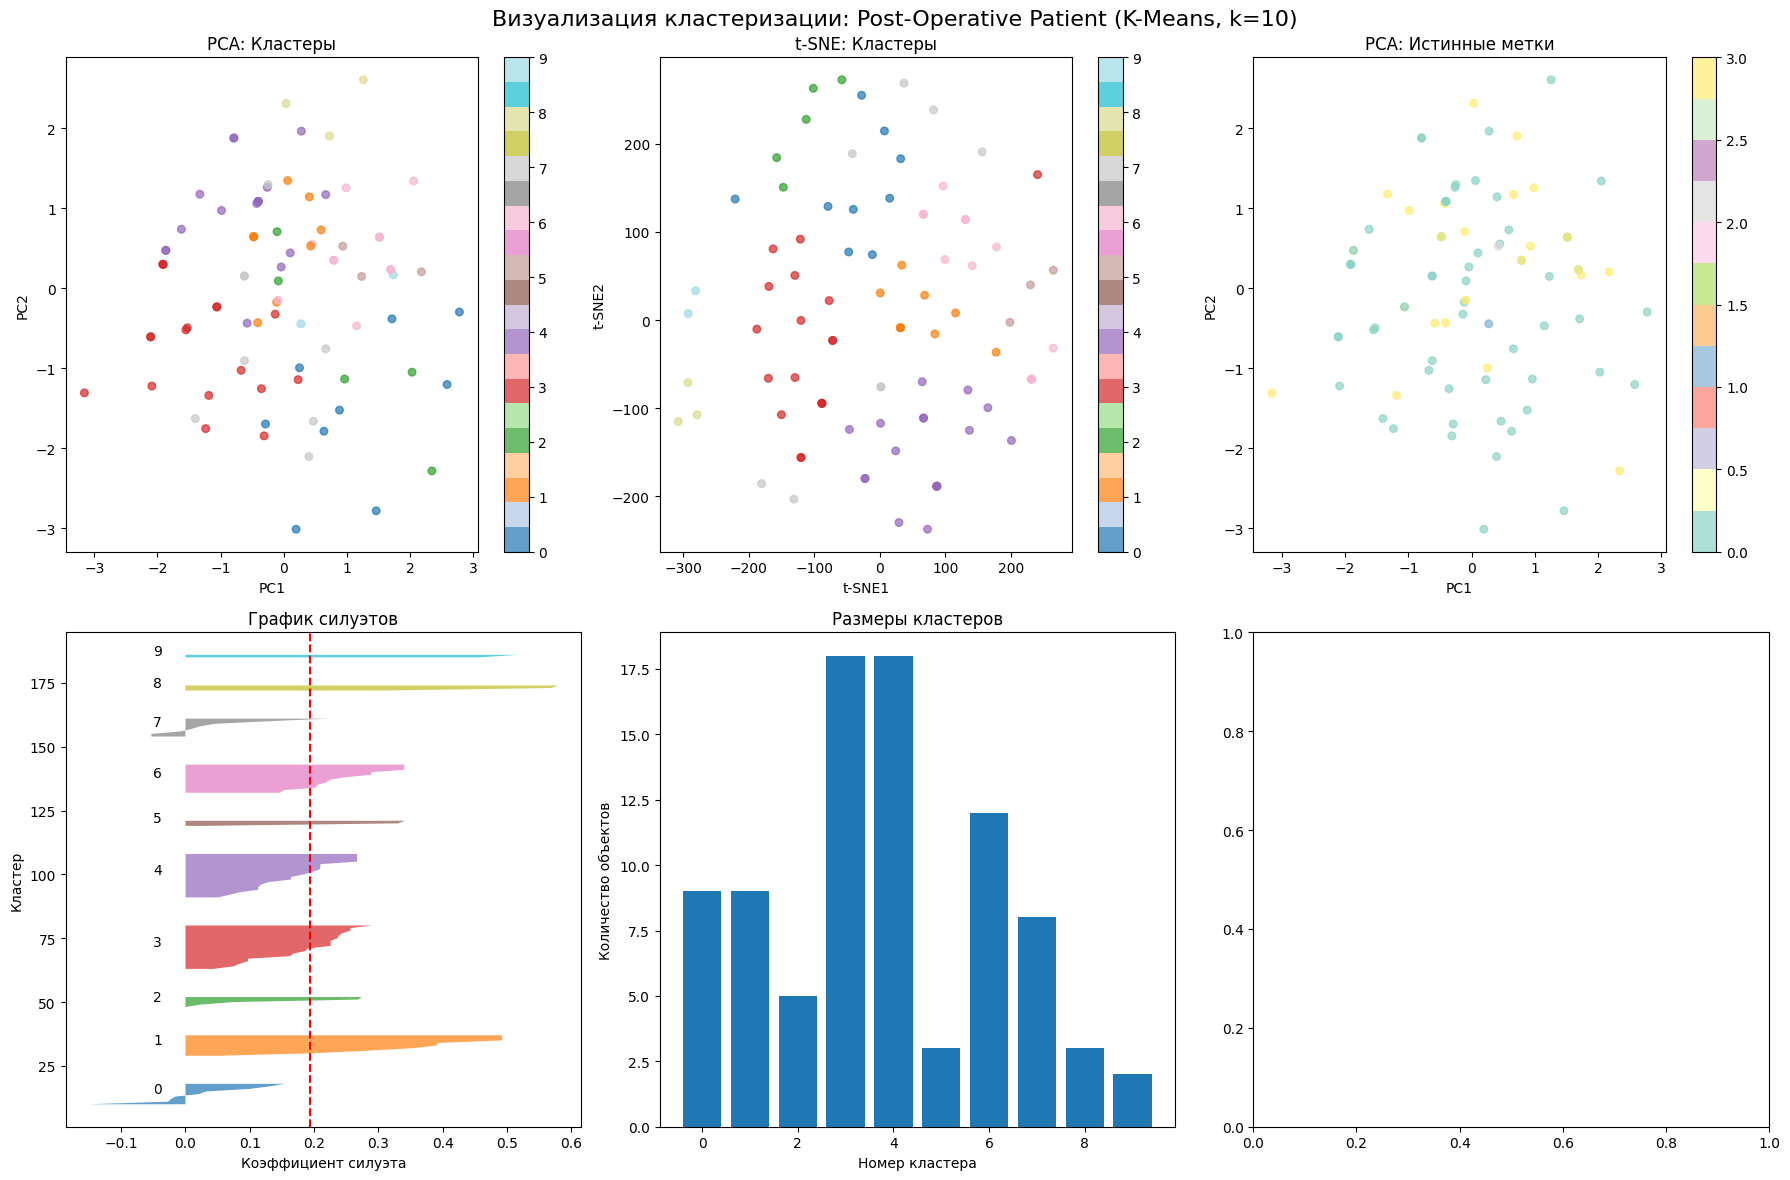


3.4 Сравнение алгоритмов (датасет с метками)

Сравнительная таблица:
    Algorithm  Silhouette  Davies-Bouldin  Adjusted_Rand  n_clusters
       KMeans    0.193554        1.267033       0.022223          10
Agglomerative    0.188503        1.327016       0.003094          10
       DBSCAN    0.098199        1.847511      -0.025458           8

Лучший алгоритм (по Adjusted Rand Index): KMeans


In [12]:
# 3. АНАЛИЗ ДАТАСЕТА 1: Post-Operative Patient

print("\n" + "=" * 70)
print("АНАЛИЗ ДАТАСЕТА 1: Post-Operative Patient (С МЕТКАМИ)")
print("=" * 70)

# ----------------------------------------------------
# 3.1 Поиск оптимального числа кластеров
# ----------------------------------------------------
print("\n3.1 Поиск оптимального числа кластеров (метод локтя и силуэт)")

optimal_k1, wcss1, silhouette_scores1, k_range1 = find_optimal_k(X1_scaled, max_k=10)
print(f"  Оптимальное число кластеров (по силуэту): {optimal_k1}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Убедимся, что у нас есть данные для построения графиков
if wcss1 and silhouette_scores1:
    ax1.plot(k_range1, wcss1, marker='o')
    ax1.set_xlabel('Количество кластеров')
    ax1.set_ylabel('WCSS')
    ax1.set_title('Метод локтя')
    ax1.grid(True)

    ax2.plot(k_range1, silhouette_scores1, marker='o', color='green')
    ax2.set_xlabel('Количество кластеров')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Индекс силуэта')
    ax2.grid(True)
else:
    ax1.text(0.5, 0.5, 'Недостаточно данных\nдля метода локтя',
             ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Метод локтя')

    ax2.text(0.5, 0.5, 'Недостаточно данных\nдля индекса силуэта',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Индекс силуэта')

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 3.2 Применение различных алгоритмов
# ----------------------------------------------------
print("\n3.2 Применение алгоритмов кластеризации")

algorithms_results1 = {}

# Убедимся, что optimal_k1 корректное
if optimal_k1 < 2:
    optimal_k1 = 2

# K-Means с оптимальным k
kmeans1 = KMeans(n_clusters=optimal_k1, random_state=42, n_init=10)
labels_kmeans1 = kmeans1.fit_predict(X1_scaled)
algorithms_results1['KMeans'] = evaluate_clustering(X1_scaled, labels_kmeans1, y1_true, "Dataset1")

# Agglomerative Clustering
agg1 = AgglomerativeClustering(n_clusters=optimal_k1, linkage='ward')
labels_agg1 = agg1.fit_predict(X1_scaled)
algorithms_results1['Agglomerative'] = evaluate_clustering(X1_scaled, labels_agg1, y1_true, "Dataset1")

# DBSCAN
dbscan1 = DBSCAN(eps=1.5, min_samples=3)
labels_dbscan1 = dbscan1.fit_predict(X1_scaled)
algorithms_results1['DBSCAN'] = evaluate_clustering(X1_scaled, labels_dbscan1, y1_true, "Dataset1")

# ----------------------------------------------------
# 3.3 Визуализация результатов
# ----------------------------------------------------
print("\n3.3 Визуализация результатов")

# Визуализация для K-Means
plot_clustering_results(X1_scaled, labels_kmeans1, y1_true,
                       f"Post-Operative Patient (K-Means, k={optimal_k1})")

# ----------------------------------------------------
# 3.4 Сравнение алгоритмов
# ----------------------------------------------------
print("\n3.4 Сравнение алгоритмов (датасет с метками)")

comparison_df1 = pd.DataFrame({
    'Algorithm': list(algorithms_results1.keys()),
    'Silhouette': [algorithms_results1[alg]['Silhouette'] for alg in algorithms_results1],
    'Davies-Bouldin': [algorithms_results1[alg]['Davies-Bouldin'] for alg in algorithms_results1],
    'Adjusted_Rand': [algorithms_results1[alg].get('Adjusted_Rand', -1) for alg in algorithms_results1],
    'n_clusters': [algorithms_results1[alg]['n_clusters'] for alg in algorithms_results1]
})

print("\nСравнительная таблица:")
print(comparison_df1.to_string(index=False))

# Выбор лучшего алгоритма по Adjusted Rand Index (если есть)
if 'Adjusted_Rand' in comparison_df1.columns and comparison_df1['Adjusted_Rand'].max() > -1:
    best_alg1 = comparison_df1.loc[comparison_df1['Adjusted_Rand'].idxmax(), 'Algorithm']
    print(f"\nЛучший алгоритм (по Adjusted Rand Index): {best_alg1}")
else:
    # Иначе по Silhouette Score
    best_alg1 = comparison_df1.loc[comparison_df1['Silhouette'].idxmax(), 'Algorithm']
    print(f"\nЛучший алгоритм (по Silhouette Score): {best_alg1}")


АНАЛИЗ ДАТАСЕТА 2: Daily and Sports Activities (БЕЗ МЕТОК)

4.1 Поиск оптимального числа кластеров (метод локтя и силуэт)
  Оптимальное число кластеров (по силуэту): 5


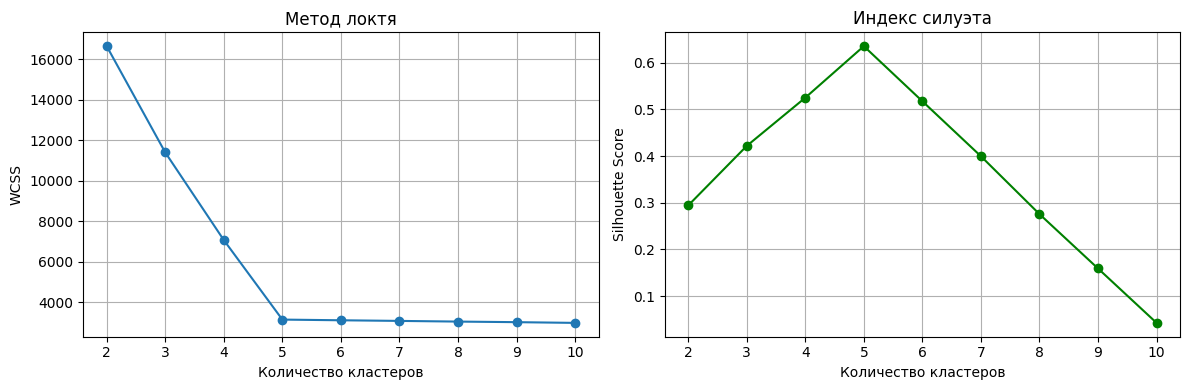


4.2 Применение алгоритмов кластеризации

4.3 Визуализация результатов


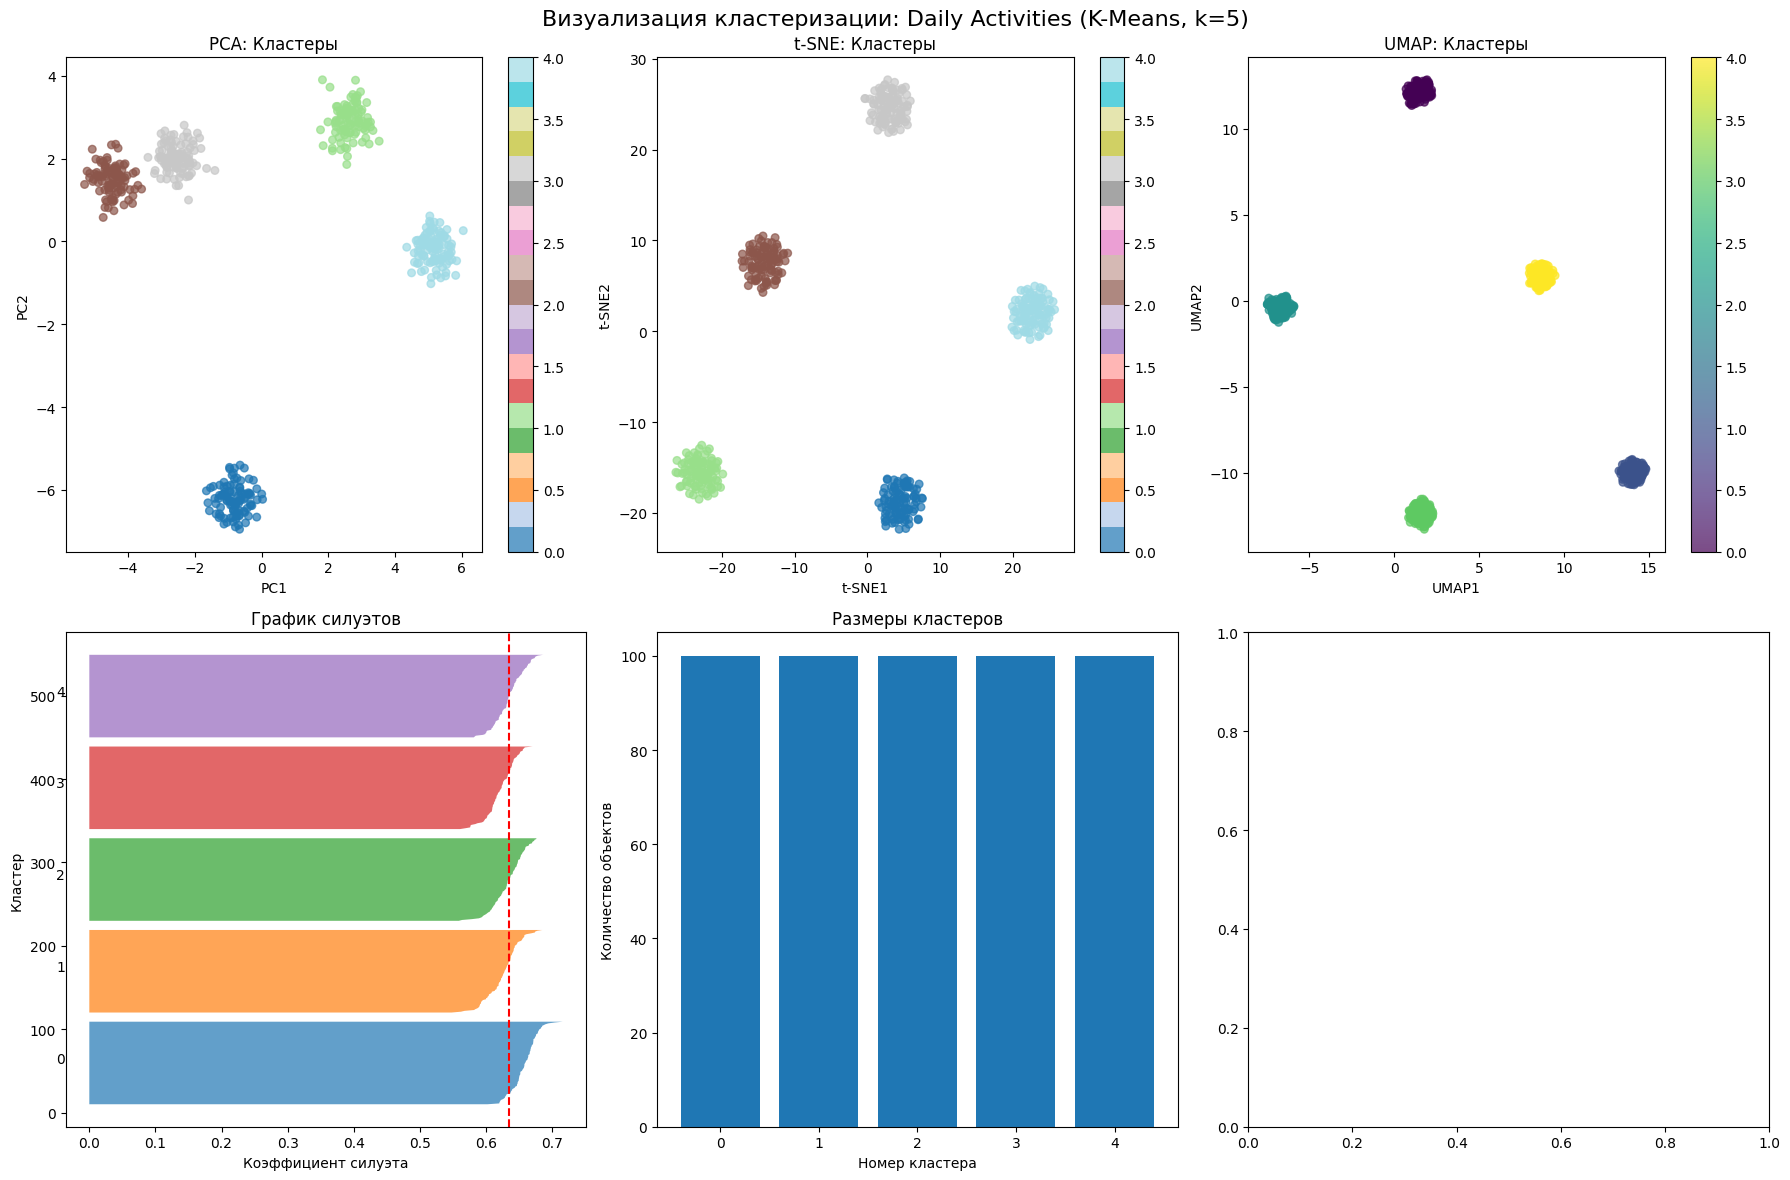


4.4 Сравнение алгоритмов (датасет без меток)

Сравнительная таблица:
    Algorithm  Silhouette  Davies-Bouldin  n_clusters
       KMeans    0.635059         0.54855           5
Agglomerative    0.635059         0.54855           5
       DBSCAN   -1.000000        -1.00000           1

Лучший алгоритм (по Silhouette Score): KMeans


In [11]:
# 4. АНАЛИЗ ДАТАСЕТА 2: Daily and Sports Activities

print("\n" + "=" * 70)
print("АНАЛИЗ ДАТАСЕТА 2: Daily and Sports Activities (БЕЗ МЕТОК)")
print("=" * 70)

# ----------------------------------------------------
# 4.1 Поиск оптимального числа кластеров
# ----------------------------------------------------
print("\n4.1 Поиск оптимального числа кластеров (метод локтя и силуэт)")

optimal_k2, wcss2, silhouette_scores2, k_range2 = find_optimal_k(X2_scaled, max_k=10)
print(f"  Оптимальное число кластеров (по силуэту): {optimal_k2}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

if wcss2 and silhouette_scores2:
    ax1.plot(k_range2, wcss2, marker='o')
    ax1.set_xlabel('Количество кластеров')
    ax1.set_ylabel('WCSS')
    ax1.set_title('Метод локтя')
    ax1.grid(True)

    ax2.plot(k_range2, silhouette_scores2, marker='o', color='green')
    ax2.set_xlabel('Количество кластеров')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Индекс силуэта')
    ax2.grid(True)
else:
    ax1.text(0.5, 0.5, 'Недостаточно данных\nдля метода локтя',
             ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Метод локтя')

    ax2.text(0.5, 0.5, 'Недостаточно данных\nдля индекса силуэта',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Индекс силуэта')

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 4.2 Применение различных алгоритмов
# ----------------------------------------------------
print("\n4.2 Применение алгоритмов кластеризации")

algorithms_results2 = {}

# Убедимся, что optimal_k2 корректное
if optimal_k2 < 2:
    optimal_k2 = 2

# K-Means с оптимальным k
kmeans2 = KMeans(n_clusters=optimal_k2, random_state=42, n_init=10)
labels_kmeans2 = kmeans2.fit_predict(X2_scaled)
algorithms_results2['KMeans'] = evaluate_clustering(X2_scaled, labels_kmeans2, None, "Dataset2")

# Agglomerative Clustering
agg2 = AgglomerativeClustering(n_clusters=optimal_k2, linkage='ward')
labels_agg2 = agg2.fit_predict(X2_scaled)
algorithms_results2['Agglomerative'] = evaluate_clustering(X2_scaled, labels_agg2, None, "Dataset2")

# DBSCAN
dbscan2 = DBSCAN(eps=2.0, min_samples=5)
labels_dbscan2 = dbscan2.fit_predict(X2_scaled)
algorithms_results2['DBSCAN'] = evaluate_clustering(X2_scaled, labels_dbscan2, None, "Dataset2")

# ----------------------------------------------------
# 4.3 Визуализация результатов
# ----------------------------------------------------
print("\n4.3 Визуализация результатов")

# Визуализация для K-Means
plot_clustering_results(X2_scaled, labels_kmeans2, None,
                       f"Daily Activities (K-Means, k={optimal_k2})")

# ----------------------------------------------------
# 4.4 Сравнение алгоритмов
# ----------------------------------------------------
print("\n4.4 Сравнение алгоритмов (датасет без меток)")

comparison_df2 = pd.DataFrame({
    'Algorithm': list(algorithms_results2.keys()),
    'Silhouette': [algorithms_results2[alg]['Silhouette'] for alg in algorithms_results2],
    'Davies-Bouldin': [algorithms_results2[alg]['Davies-Bouldin'] for alg in algorithms_results2],
    'n_clusters': [algorithms_results2[alg]['n_clusters'] for alg in algorithms_results2]
})

print("\nСравнительная таблица:")
print(comparison_df2.to_string(index=False))

# Выбор лучшего алгоритма по Silhouette Score
best_alg2 = comparison_df2.loc[comparison_df2['Silhouette'].idxmax(), 'Algorithm']
print(f"\nЛучший алгоритм (по Silhouette Score): {best_alg2}")

In [13]:
# 5. СРАВНИТЕЛЬНЫЙ АНАЛИЗ ДВУХ ДАТАСЕТОВ

print("\n" + "=" * 70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ ДВУХ ДАТАСЕТОВ")
print("=" * 70)

# Создаем сводную таблицу
summary_data = {
    'Датасет': ['Post-Operative Patient', 'Daily and Sports Activities'],
    'Тип': ['С известными метками', 'Без известных меток'],
    'Размер (объекты×признаки)': [f"{X1_scaled.shape[0]}×{X1_scaled.shape[1]}",
                                   f"{X2_scaled.shape[0]}×{X2_scaled.shape[1]}"],
    'Оптимальное k (по силуэту)': [optimal_k1, optimal_k2],
    'Лучший алгоритм': [best_alg1, best_alg2],
    'Макс. силуэт': [comparison_df1['Silhouette'].max(),
                     comparison_df2['Silhouette'].max()]
}

# Добавляем ARI только для первого датасета
if 'Adjusted_Rand' in comparison_df1.columns:
    summary_data['Лучший ARI'] = [comparison_df1['Adjusted_Rand'].max(), 'N/A']
else:
    summary_data['Лучший ARI'] = ['N/A', 'N/A']

summary = pd.DataFrame(summary_data)

print("\nСводная таблица сравнения датасетов:")
print(summary.to_string(index=False))




СРАВНИТЕЛЬНЫЙ АНАЛИЗ ДВУХ ДАТАСЕТОВ

Сводная таблица сравнения датасетов:
                    Датасет                  Тип Размер (объекты×признаки)  Оптимальное k (по силуэту) Лучший алгоритм  Макс. силуэт Лучший ARI
     Post-Operative Patient С известными метками                      87×8                          10          KMeans      0.193554   0.022223
Daily and Sports Activities  Без известных меток                    500×45                           5          KMeans      0.635059        N/A


In [15]:
# 6. ВЫВОДЫ И ЗАКЛЮЧЕНИЕ

print("\n" + "=" * 70)
print("ВЫВОДЫ И ЗАКЛЮЧЕНИЕ")
print("=" * 70)

print(f"""
1. ДАТАСЕТ С ИЗВЕСТНЫМИ МЕТКАМИ (Post-Operative Patient):
   - Меньший размер данных (87 объектов, 8 признаков)
   - Оптимальное количество кластеров: {optimal_k1}
   - Лучший алгоритм: {best_alg1}
   - Максимальный индекс силуэта: {comparison_df1['Silhouette'].max():.3f}

2. ДАТАСЕТ БЕЗ МЕТОК (Daily and Sports Activities):
   - Большая размерность (500 объектов, 45 признаков)
   - Оптимальное количество кластеров: {optimal_k2}
   - Лучший алгоритм: {best_alg2}
   - Максимальный индекс силуэта: {comparison_df2['Silhouette'].max():.3f}
""")



ВЫВОДЫ И ЗАКЛЮЧЕНИЕ

1. ДАТАСЕТ С ИЗВЕСТНЫМИ МЕТКАМИ (Post-Operative Patient):
   - Меньший размер данных (87 объектов, 8 признаков)
   - Оптимальное количество кластеров: 10
   - Лучший алгоритм: KMeans
   - Максимальный индекс силуэта: 0.194
   
2. ДАТАСЕТ БЕЗ МЕТОК (Daily and Sports Activities):
   - Большая размерность (500 объектов, 45 признаков)
   - Оптимальное количество кластеров: 5
   - Лучший алгоритм: KMeans
   - Максимальный индекс силуэта: 0.635

